# 🎓 Face Recognition Attendance System — Interactive Demo

| Cell | Does |
|------|------|
| **1** | Imports & project path setup |
| **2** | Load YOLO + ArcFace + Classifier |
| **3** | YOLO detection on one image — shows boxes + landmarks |
| **4** | Aligned 112×112 face crops |
| **5** | ArcFace embedding heatmaps + cosine similarity matrix |
| **6** | Classify + annotated classroom image |
| **7** | All session images processed + majority voting |
| **8** | Final attendance table + confidence chart |
| **9** | Save CSV |
| **10** | Evaluation on held-out test set |

---
> **Run `scripts/run_enrollment.py` first** so `models/classifier.pkl` and `data/embeddings/` exist.

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports & Path Setup                                   ║
# ╚══════════════════════════════════════════════════════════════════╝
import sys, os, json, csv, warnings
from pathlib  import Path
from datetime import datetime
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Point to your AAS project root ──────────────────────────────────
# If this notebook is inside  AAS/notebooks/  use  ".."  (default)
# If it is in the project root itself, change to  "."
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'✓ sys.path includes: {PROJECT_ROOT}')

✓ sys.path includes: c:\Users\KIIT0001\Desktop\Smart_AAS


In [2]:
# ── Load metadata ────────────────────────────────────────────────────
from config import *

with open(Path(PATHS['embeddings_dir']) / 'metadata.json') as f:
    meta = json.load(f)

NAME_MAP  = {int(k): v for k, v in meta['names_map'].items()}   # idx → name
indices   = sorted(NAME_MAP.keys())
ALL_NAMES = [NAME_MAP[i] for i in indices]

print(f'\n✓ Ready. {len(ALL_NAMES)} enrolled students:')
for n in ALL_NAMES:
    print(f'   {n}')


✓ Ready. 62 enrolled students:
   AARUNI SAHAY
   Aayansh Jaiswal
   AAYUSH HORE
   ABHINAV KUMAR
   Abhiraj
   ADITI JAIN
   Aditya Anand
   ADITYA JAGGI
   ADITYA PATHAK
   ANANWAY GOSWAMI
   Anirban Modak
   ANSITA RAY
   ARYAN SINGH
   AVINASH SINGH
   Biswarup Mahapatra
   DEBABRAT MAHANTO
   Evelyn Johnson
   HIMANSHU SINGH
   ISHAAN CHAKRABORTY
   JEET NASKAR
   Keshab Agarwal
   KRISHNA RAKSHIT
   Lucky Jha
   Manasi Mohanty
   Manimoy Karmakar
   MANSHI MEHUL
   MD TAYEEB
   MEGHA KUMARI
   Mohul
   Monojit Pal
   PALLAB GHOSH
   Parth Raj
   PBIDYUSMITA PATRO
   PRANJAL SINHA
   PULAK MOHANTY
   Pulkit Raj
   RAJASHREE DAS
   RAMYA PANDA
   RITESH PATEL
   SAMPRITI RAY
   SAMRIDDHA BAGCHI
   SANIDHYA RAYAL
   SANSKRITI VASHISHTHA
   Sarthak Dash
   SASWAT PRADHAN
   Satyam Kumar
   SHANKHADEEP PAUL
   SHIVAM SINGH
   Shivangi Sinha
   SOURAV SANU
   Souvik Mandal
   SREERAJ SAHA
   SRIJAN BASU
   Srijan Das
   STUTI SHAH
   SUBHAM MAITI
   SUKRIT DUTTA
   SUMEDHA CHATTOPADHY

Embeddings: 6561 total across 62 students
Embedding norms: 1.000 (should be ~1.0)


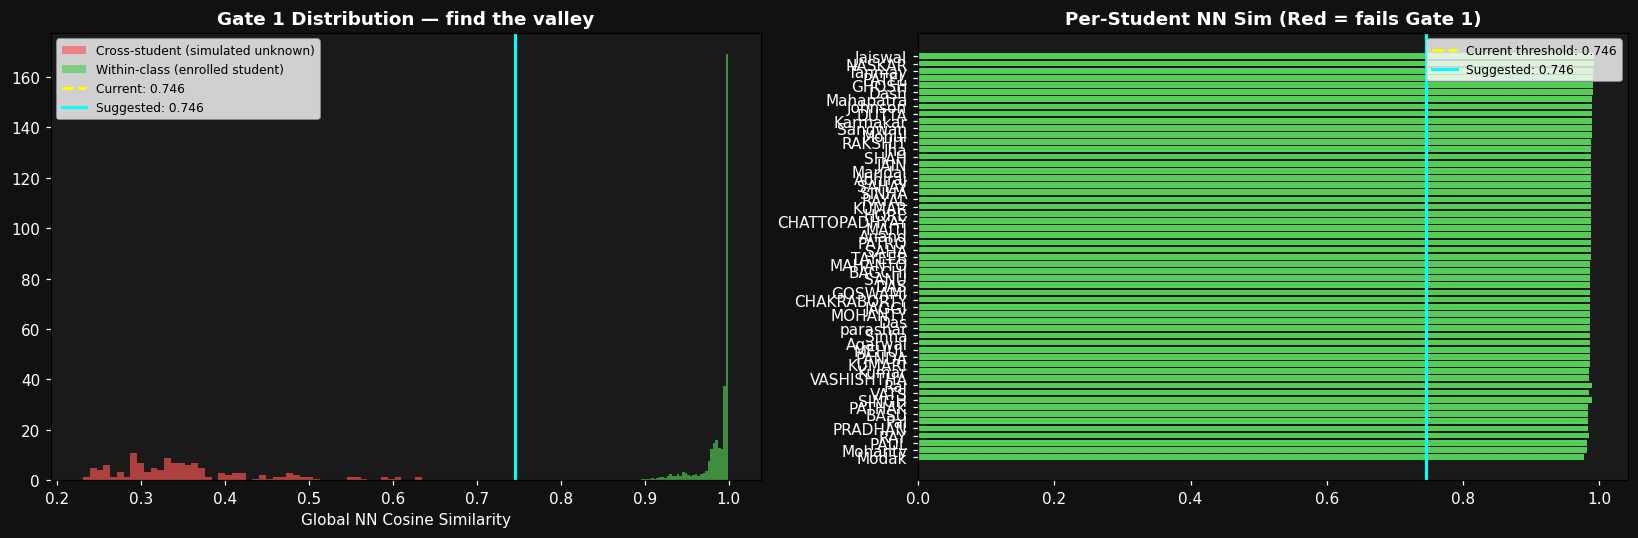


Current global_nn_threshold : 0.746
Within-class sim: mean=0.987  min=0.846  p5=0.939
Cross-class sim:  mean=0.357  max=0.634  p95=0.554

0.0% of enrolled embeddings FAIL Gate 1 at current threshold
→ Suggested global_nn_threshold: 0.746

To apply: update config.py → RECOGNITION["global_nn_threshold"] = 0.746
Then re-run Cell 2 to reload classifier.


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  DIAGNOSTIC CELL — Run after Cell 2 to tune thresholds         ║
# ║  Shows why students are being rejected and what values to use   ║
# ╚══════════════════════════════════════════════════════════════════╝
# This reads your actual embeddings and plots the similarity
# distributions so you can pick the right global_nn_threshold.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

emb_dir    = Path(PATHS['embeddings_dir'])
train_embs = np.load(emb_dir / 'train_embeddings.npy')
train_lbls = np.load(emb_dir / 'train_labels.npy')
n_students = len(np.unique(train_lbls))
print(f'Embeddings: {len(train_embs)} total across {n_students} students')
print(f'Embedding norms: {np.linalg.norm(train_embs,axis=1).mean():.3f} (should be ~1.0)')

# ── Within-class similarities (what enrolled students score against themselves)
within_sims = []
for label in np.unique(train_lbls):
    mask = train_lbls == label
    embs = train_embs[mask]
    for i, e in enumerate(embs):
        rest = np.delete(embs, i, axis=0)
        if len(rest): within_sims.append(float(np.max(rest @ e)))
within_sims = np.array(within_sims)

# ── Cross-class similarities (proxy for unknown person)
cross_sims = []
for label in np.unique(train_lbls):
    probe = train_embs[train_lbls == label]
    gallery = train_embs[train_lbls != label]
    for e in probe[:3]:  # 3 samples per student
        cross_sims.append(float(np.max(gallery @ e)))
cross_sims = np.array(cross_sims)

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#111')

axes[0].hist(cross_sims,  bins=50, alpha=0.65, color='#FF5555',
             density=True, label='Cross-student (simulated unknown)')
axes[0].hist(within_sims, bins=50, alpha=0.65, color='#55CC55',
             density=True, label='Within-class (enrolled student)')

current = RECOGNITION.get('global_nn_threshold', 0.50)
suggested = round((np.percentile(within_sims, 5) + np.percentile(cross_sims, 95)) / 2, 3)
axes[0].axvline(current,   color='yellow', linestyle='--', lw=2, label=f'Current: {current}')
axes[0].axvline(suggested, color='cyan',   linestyle='-',  lw=2, label=f'Suggested: {suggested}')
axes[0].set_facecolor('#1a1a1a')
axes[0].set_xlabel('Global NN Cosine Similarity', color='white')
axes[0].set_title('Gate 1 Distribution — find the valley', color='white', fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].legend(fontsize=8)

# ── Per-student min similarity bar chart
per_student = []
for label in np.unique(train_lbls):
    mask = train_lbls == label
    embs = train_embs[mask]
    sims = []
    for i, e in enumerate(embs):
        rest = np.delete(embs, i, axis=0)
        if len(rest): sims.append(float(np.max(rest @ e)))
    if sims: per_student.append((NAME_MAP[int(label)].split()[-1], np.mean(sims)))
per_student.sort(key=lambda x: x[1])
names_ps = [x[0] for x in per_student]
vals_ps  = [x[1] for x in per_student]
colors_ps = ['#CC3333' if v < current else '#55CC55' for v in vals_ps]
axes[1].barh(names_ps, vals_ps, color=colors_ps, edgecolor='none')
axes[1].axvline(current, color='yellow', linestyle='--', lw=2, label=f'Current threshold: {current}')
axes[1].axvline(suggested, color='cyan', linestyle='-', lw=2, label=f'Suggested: {suggested}')
axes[1].set_facecolor('#1a1a1a')
axes[1].set_title('Per-Student NN Sim (Red = fails Gate 1)', color='white', fontweight='bold')
axes[1].tick_params(colors='white')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

pct_failing = (within_sims < current).mean() * 100
print(f'\nCurrent global_nn_threshold : {current}')
print(f'Within-class sim: mean={within_sims.mean():.3f}  '
      f'min={within_sims.min():.3f}  p5={np.percentile(within_sims,5):.3f}')
print(f'Cross-class sim:  mean={cross_sims.mean():.3f}  '
      f'max={cross_sims.max():.3f}  p95={np.percentile(cross_sims,95):.3f}')
print(f'\n{pct_failing:.1f}% of enrolled embeddings FAIL Gate 1 at current threshold')
print(f'→ Suggested global_nn_threshold: {suggested}')
print(f'\nTo apply: update config.py → RECOGNITION["global_nn_threshold"] = {suggested}')
print('Then re-run Cell 2 to reload classifier.')


In [4]:
from src.detector import YOLOFaceDetector
from src.aligner import FaceAligner  
from src.embedder import FaceEmbedder
from src.classifier import EnsembleClassifier

# Instantiate modules
detector = YOLOFaceDetector(PATHS['yolo_weights'])
aligner = FaceAligner()
embedder = FaceEmbedder()
classifier = EnsembleClassifier.load(PATHS['classifier'])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


Found 6 session images:
   1000117519.jpg
   1000117525.jpg
   1000117528.jpg
   1000117531.jpg
   1000117534.jpg
   1000117537.jpg


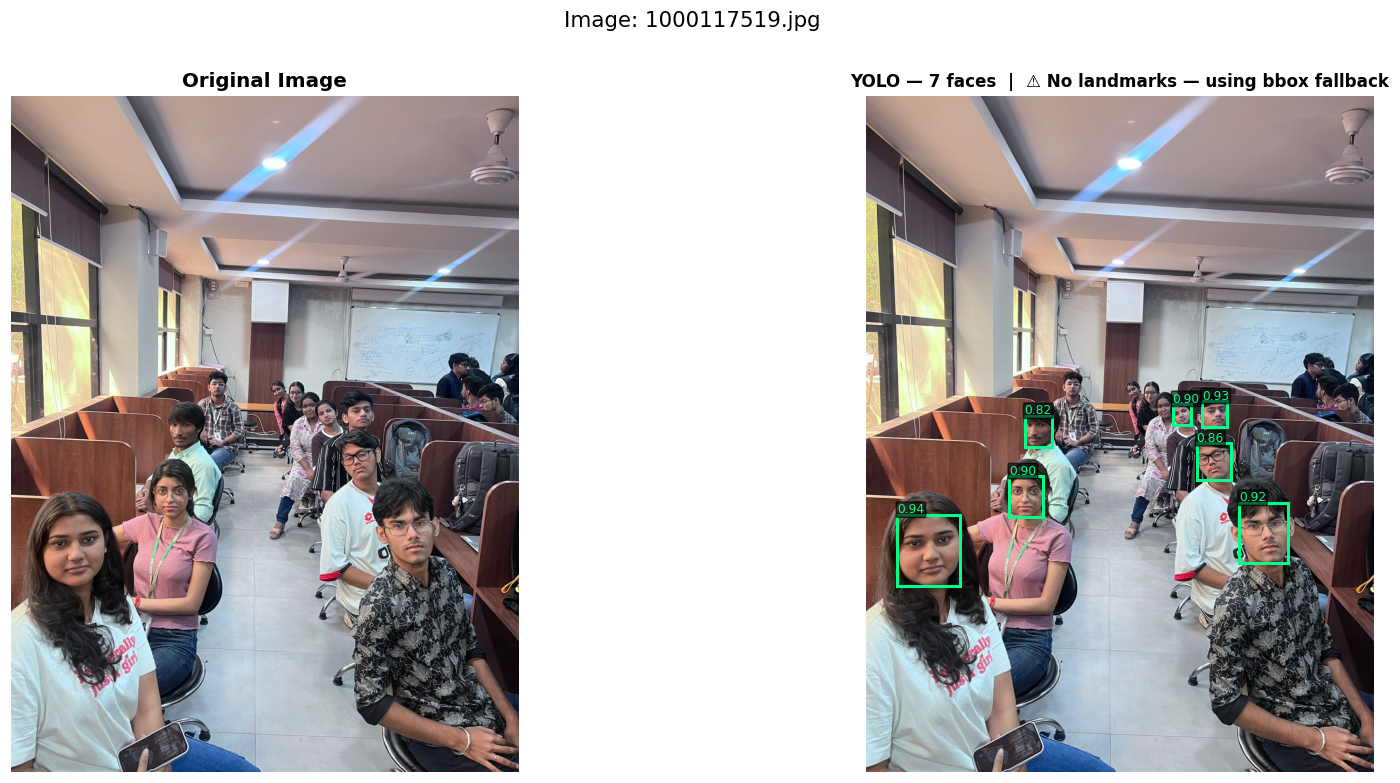


7 faces detected
  Face  1: conf=0.940  bbox=[73, 991, 221, 1160]  landmarks=NO
  Face  2: conf=0.903  bbox=[338, 900, 418, 996]  landmarks=NO
  Face  3: conf=0.823  bbox=[374, 757, 438, 830]  landmarks=NO
  Face  4: conf=0.904  bbox=[724, 729, 767, 778]  landmarks=NO
  Face  5: conf=0.857  bbox=[781, 822, 861, 908]  landmarks=NO
  Face  6: conf=0.927  bbox=[794, 722, 853, 784]  landmarks=NO
  Face  7: conf=0.919  bbox=[881, 963, 997, 1106]  landmarks=NO


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — YOLO Detection on One Image                          ║
# ╚══════════════════════════════════════════════════════════════════╝
# Session images live directly inside  data/classroom_sessions/
# (flat layout — no sub-folder needed)

SESSION_DIR = Path(PATHS['sessions_dir'])
session_images = sorted(
    list(SESSION_DIR.glob('*.jpg')) +
    list(SESSION_DIR.glob('*.jpeg')) +
    list(SESSION_DIR.glob('*.png'))
)
print(f'Found {len(session_images)} session images:')
for p in session_images:
    print(f'   {p.name}')

# ── Pick one image to visualise ──────────────────────────────────────
# Change 0 → 1, 2, 3 ... to see different images
IMG_INDEX       = 0
DEMO_IMAGE_PATH = session_images[IMG_INDEX]

image_bgr  = cv2.imread(str(DEMO_IMAGE_PATH))
image_rgb  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
detections = detector.detect(image_bgr)

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(image_rgb)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(image_rgb)
LM_COLORS = ['cyan', 'blue', 'yellow', 'magenta', 'orange']
for det in detections:
    x1, y1, x2, y2 = det.bbox
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='#00FF88', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(x1, y1-4, f'{det.confidence:.2f}', color='#00FF88', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.6))
    if det.landmarks is not None:
        for (lx, ly), c in zip(det.landmarks.astype(int), LM_COLORS):
            axes[1].plot(lx, ly, 'o', color=c, markersize=3)

has_lm = any(d.landmarks is not None for d in detections)
lm_txt = '✓ Landmarks (5-pt affine align)' if has_lm else '⚠ No landmarks — using bbox fallback'
axes[1].set_title(f'YOLO — {len(detections)} faces  |  {lm_txt}', fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.suptitle(f'Image: {DEMO_IMAGE_PATH.name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n{len(detections)} faces detected')
for i, d in enumerate(detections):
    print(f'  Face {i+1:2d}: conf={d.confidence:.3f}  '
          f'bbox={d.bbox.tolist()}  '
          f'landmarks={"yes" if d.landmarks is not None else "NO"}')

Aligned 7 / 7 faces


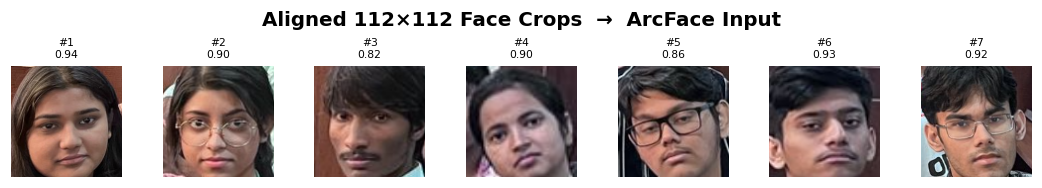

In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Face Alignment: 112×112 Crops                        ║
# ╚══════════════════════════════════════════════════════════════════╝
# Each face is affine-warped to ArcFace's canonical 112×112 space.
# ArcFace was trained on EXACTLY these coordinates — misalignment
# shifts embeddings off the training distribution and hurts accuracy.

aligned_faces, valid_dets = [], []
for det in detections:
    crop = aligner.align(image_bgr, det)
    if crop is not None:
        aligned_faces.append(crop)
        valid_dets.append(det)

print(f'Aligned {len(aligned_faces)} / {len(detections)} faces')

n    = len(aligned_faces)
cols = min(10, n)
rows = max(1, (n + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.7))
axes = np.array(axes).flatten()

for idx, (face, ax) in enumerate(zip(aligned_faces, axes)):
    ax.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    ax.set_title(f'#{idx+1}\n{valid_dets[idx].confidence:.2f}', fontsize=7)
    ax.axis('off')
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Aligned 112×112 Face Crops  →  ArcFace Input', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Extracted 7 / 7 embeddings


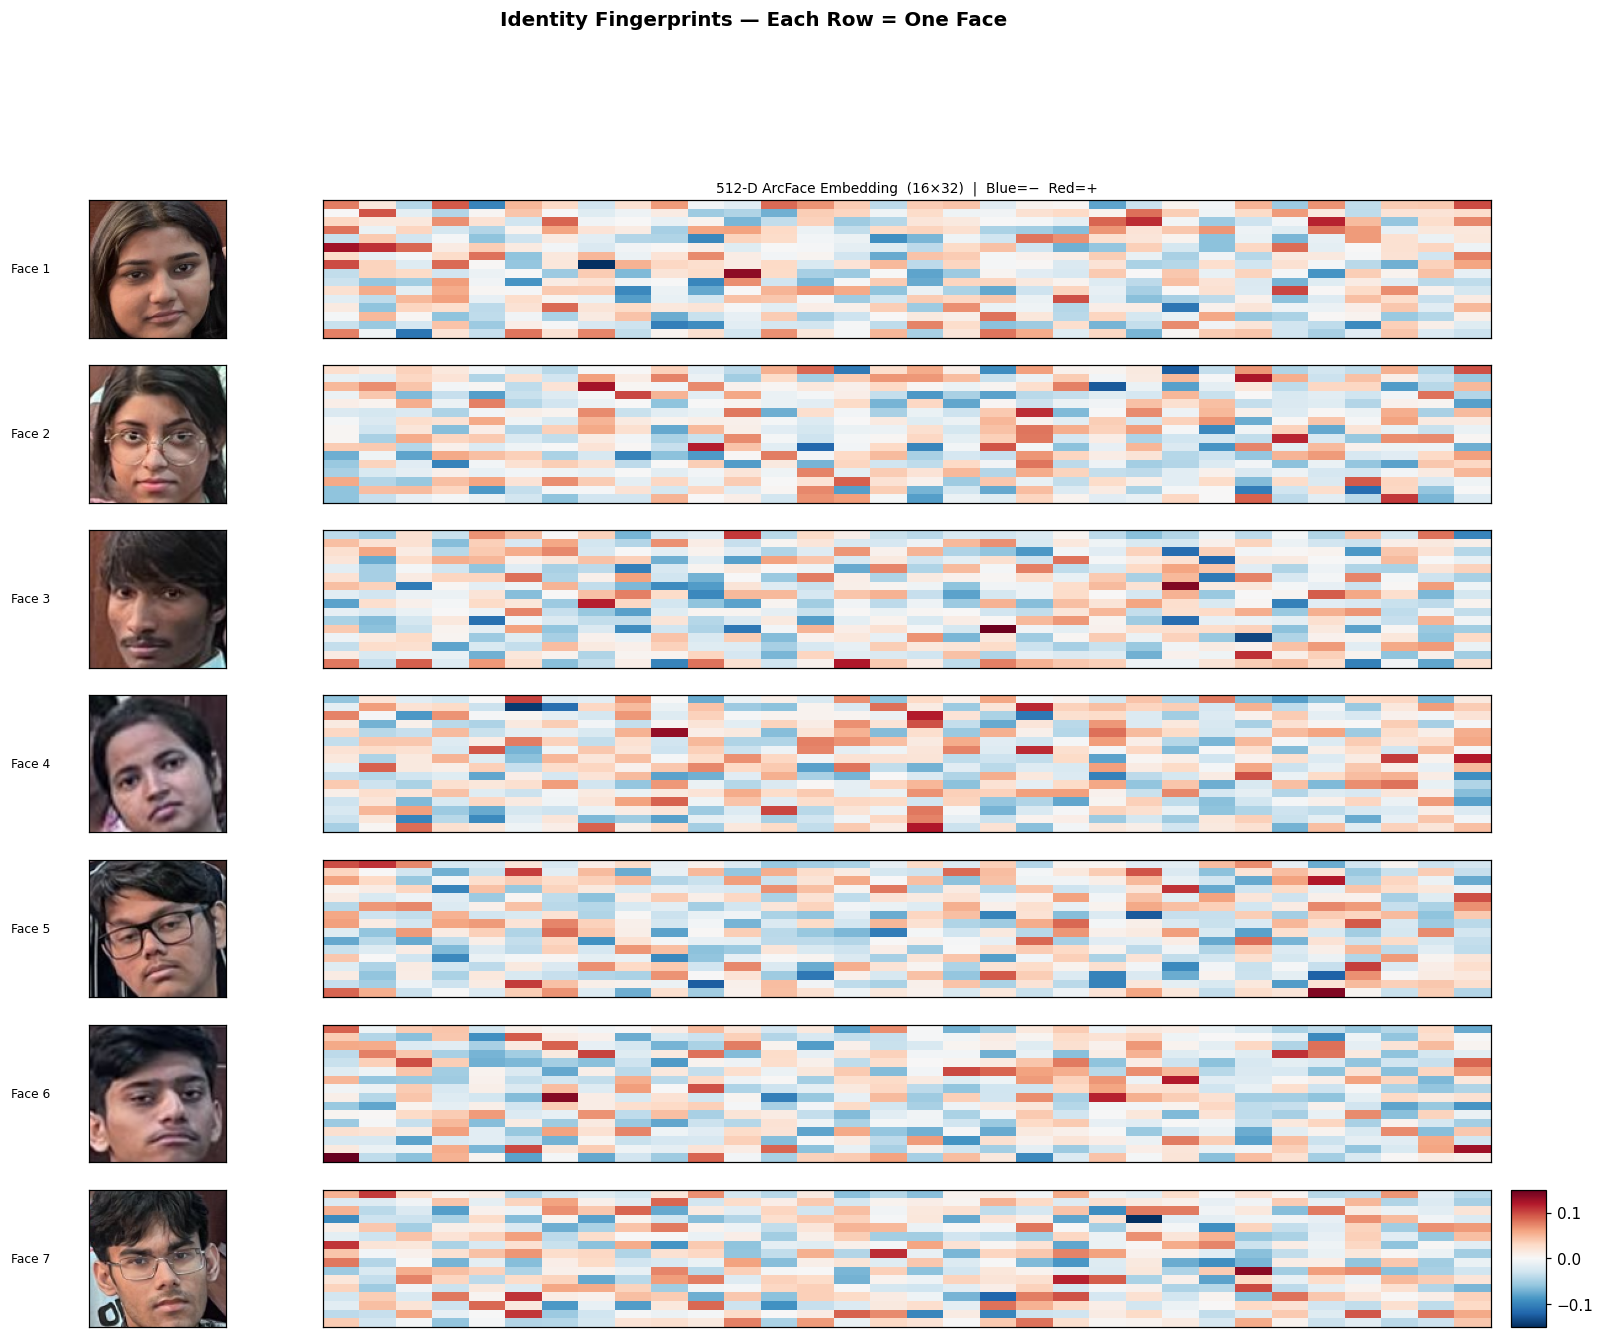

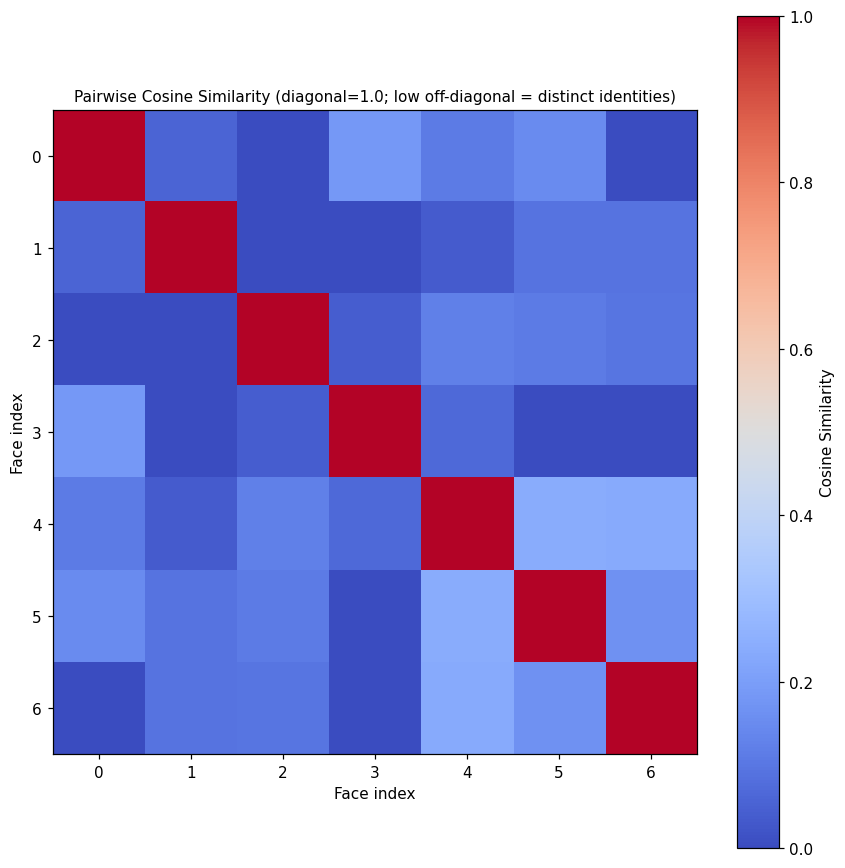

In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — ArcFace Embedding Heatmaps                           ║
# ╚══════════════════════════════════════════════════════════════════╝
# Each face → 512-D L2-normalised embedding vector.
# Visualised as a 16×32 heatmap: each cell = one embedding dimension.
# Also shows pairwise cosine similarity between all detected faces.

embeddings = [embedder.embed(f) for f in aligned_faces]
valid_embs = [(e, f, d) for e, f, d in zip(embeddings, aligned_faces, valid_dets) if e is not None]
print(f'Extracted {len(valid_embs)} / {len(aligned_faces)} embeddings')

# ── Heatmap (first 8 faces) ──────────────────────────────────────────
show_n = min(8, len(valid_embs))
fig = plt.figure(figsize=(18, show_n * 1.9))
gs  = GridSpec(show_n, 3, width_ratios=[1, 4, 0.12], wspace=0.04)
for i, (emb, face, det) in enumerate(valid_embs[:show_n]):
    ax_f = fig.add_subplot(gs[i, 0])
    ax_f.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    ax_f.set_ylabel(f'Face {i+1}', fontsize=8, rotation=0, labelpad=38, va='center')
    ax_f.set_xticks([]); ax_f.set_yticks([])

    ax_e = fig.add_subplot(gs[i, 1])
    im = ax_e.imshow(emb.reshape(16, 32), cmap='RdBu_r', aspect='auto', vmin=-0.15, vmax=0.15)
    if i == 0:
        ax_e.set_title('512-D ArcFace Embedding  (16×32)  |  Blue=−  Red=+', fontsize=9)
    ax_e.set_xticks([]); ax_e.set_yticks([])
    if i == show_n - 1:
        plt.colorbar(im, cax=fig.add_subplot(gs[i, 2]))

plt.suptitle('Identity Fingerprints — Each Row = One Face', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Pairwise cosine similarity matrix ───────────────────────────────
if len(valid_embs) > 1:
    E = np.stack([e for e, _, _ in valid_embs])
    sim = E @ E.T
    fig2, ax2 = plt.subplots(figsize=(min(10, len(valid_embs)+1), min(8, len(valid_embs)+1)))
    im2 = ax2.imshow(sim, cmap='coolwarm', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax2, label='Cosine Similarity')
    ax2.set_title('Pairwise Cosine Similarity (diagonal=1.0; low off-diagonal = distinct identities)', fontsize=10)
    ax2.set_xlabel('Face index'); ax2.set_ylabel('Face index')
    plt.tight_layout()
    plt.show()

In [8]:
# ── Load metadata ────────────────────────────────────────────────────
with open(Path(PATHS['embeddings_dir']) / 'metadata.json') as f:
    meta = json.load(f)

NAME_MAP  = {int(k): v for k, v in meta['names_map'].items()}   # idx → name
indices   = sorted(NAME_MAP.keys())
ALL_NAMES = [NAME_MAP[i] for i in indices]

print(f'\n✓ Ready. {len(ALL_NAMES)} enrolled students:')
for n in ALL_NAMES:
    print(f'   {n}')


✓ Ready. 62 enrolled students:
   AARUNI SAHAY
   Aayansh Jaiswal
   AAYUSH HORE
   ABHINAV KUMAR
   Abhiraj
   ADITI JAIN
   Aditya Anand
   ADITYA JAGGI
   ADITYA PATHAK
   ANANWAY GOSWAMI
   Anirban Modak
   ANSITA RAY
   ARYAN SINGH
   AVINASH SINGH
   Biswarup Mahapatra
   DEBABRAT MAHANTO
   Evelyn Johnson
   HIMANSHU SINGH
   ISHAAN CHAKRABORTY
   JEET NASKAR
   Keshab Agarwal
   KRISHNA RAKSHIT
   Lucky Jha
   Manasi Mohanty
   Manimoy Karmakar
   MANSHI MEHUL
   MD TAYEEB
   MEGHA KUMARI
   Mohul
   Monojit Pal
   PALLAB GHOSH
   Parth Raj
   PBIDYUSMITA PATRO
   PRANJAL SINHA
   PULAK MOHANTY
   Pulkit Raj
   RAJASHREE DAS
   RAMYA PANDA
   RITESH PATEL
   SAMPRITI RAY
   SAMRIDDHA BAGCHI
   SANIDHYA RAYAL
   SANSKRITI VASHISHTHA
   Sarthak Dash
   SASWAT PRADHAN
   Satyam Kumar
   SHANKHADEEP PAUL
   SHIVAM SINGH
   Shivangi Sinha
   SOURAV SANU
   Souvik Mandal
   SREERAJ SAHA
   SRIJAN BASU
   Srijan Das
   STUTI SHAH
   SUBHAM MAITI
   SUKRIT DUTTA
   SUMEDHA CHATTOPADHY

  1000117519.jpg: 7 detected, 7 recognised
  1000117525.jpg: 7 detected, 6 recognised
  1000117528.jpg: 10 detected, 7 recognised
  1000117531.jpg: 10 detected, 7 recognised
  1000117534.jpg: 11 detected, 8 recognised
  1000117537.jpg: 9 detected, 8 recognised


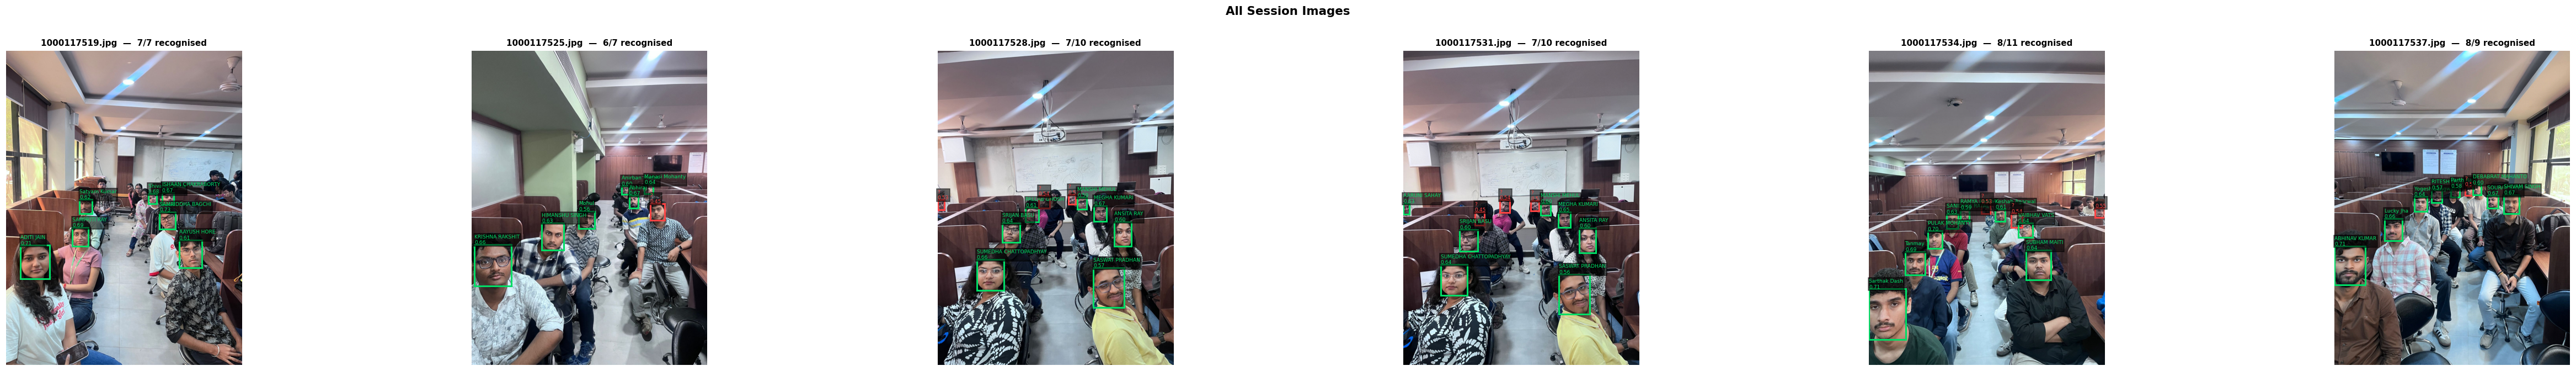

In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Full Session: All Images + Majority Voting           ║
# ╚══════════════════════════════════════════════════════════════════╝
# Processes all  data/classroom_sessions/*.jpg  images.
# Majority voting rule (from config.py):
#   PRESENT if seen in ≥ min_images_required  OR  max_conf > high_conf_override

MIN_IMGS  = AGGREGATION['min_images_required']
HIGH_CONF = AGGREGATION['high_conf_override']

votes       = defaultdict(list)   # name → [conf, conf, ...] per image
per_image   = {}                  # fname → (bgr, [(det, rec), ...])

for img_path in session_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    dets = detector.detect(img)
    img_res, seen = [], set()
    for det in dets:
        aligned = aligner.align(img, det)
        if aligned is None: continue
        emb = embedder.embed(aligned)
        if emb is None: continue
        rec = classifier.predict(emb)
        img_res.append((det, rec))
        if rec.is_known and rec.name not in seen:
            votes[rec.name].append(rec.confidence)
            seen.add(rec.name)
    per_image[img_path.name] = (img, img_res)
    print(f'  {img_path.name}: {len(dets)} detected, '
          f'{sum(1 for _,r in img_res if r.is_known)} recognised')

# ── Show all images annotated ────────────────────────────────────────
n_imgs = len(per_image)
fig, axes = plt.subplots(1, n_imgs, figsize=(n_imgs * 8, 6))
if n_imgs == 1: axes = [axes]

for ax, (fname, (img_bgr, img_res)) in zip(axes, per_image.items()):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    for det, rec in img_res:
        x1, y1, x2, y2 = det.bbox
        color = '#00DD66' if rec.is_known else '#FF4444'
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                     linewidth=2, edgecolor=color, facecolor='none'))
        label = rec.name if rec.is_known else '?'
        ax.text(x1, y1-3, f'{label}\n{rec.confidence:.2f}', color=color, fontsize=6,
                bbox=dict(facecolor='black', alpha=0.55, pad=1))
    known_n = sum(1 for _, r in img_res if r.is_known)
    ax.set_title(f'{fname}  —  {known_n}/{len(img_res)} recognised', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('All Session Images', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Name,Status,Images Seen,Avg Conf,Max Conf
AARUNI SAHAY,✓ PRESENT,1 / 6,0.625,0.625
AAYUSH HORE,✓ PRESENT,1 / 6,0.612,0.612
ABHINAV KUMAR,✓ PRESENT,1 / 6,0.712,0.712
ADITI JAIN,✓ PRESENT,1 / 6,0.709,0.709
ADITYA JAGGI,✗ ABSENT,0 / 6,0.000,0.000
ADITYA PATHAK,✗ ABSENT,0 / 6,0.000,0.000
ANANWAY GOSWAMI,✗ ABSENT,0 / 6,0.000,0.000
ANSITA RAY,✓ PRESENT,2 / 6,0.598,0.599
ARYAN SINGH,✗ ABSENT,0 / 6,0.000,0.000
AVINASH SINGH,✗ ABSENT,0 / 6,0.000,0.000


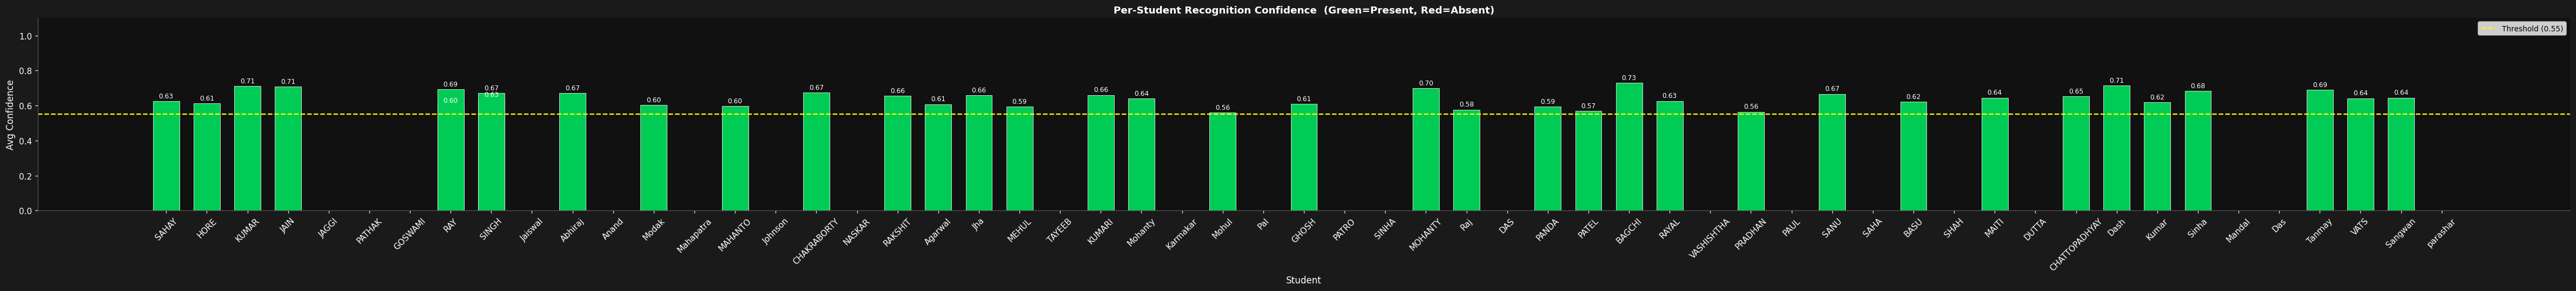

In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Final Attendance Table + Confidence Chart            ║
# ╚══════════════════════════════════════════════════════════════════╝

present_list, absent_list = [], []

for name in ALL_NAMES:
    # classifier stores roll number as 'name' key — look up by roll
    student_votes = votes.get(name, [])
    images_seen   = len(student_votes)
    max_conf      = max(student_votes)  if student_votes else 0.0
    avg_conf      = float(np.mean(student_votes)) if student_votes else 0.0
    is_present    = (images_seen >= MIN_IMGS) or (max_conf >= HIGH_CONF)

    entry = dict(name=name,
                 images_seen=images_seen, total=len(session_images),
                 avg_conf=avg_conf, max_conf=max_conf)
    (present_list if is_present else absent_list).append(entry)

all_students = sorted(present_list + absent_list, key=lambda x: x['name'])

# ── HTML table ───────────────────────────────────────────────────────
rows_html = ''
for s in all_students:
    is_p  = s in present_list
    bg    = '#0d2b0d' if is_p else '#2b0d0d'
    badge = ('<span style="color:#00EE77;font-weight:bold">✓ PRESENT</span>'
             if is_p else '<span style="color:#FF6666;font-weight:bold">✗ ABSENT</span>')
    rows_html += f'''
        <tr style="background:{bg}">
          <td style="padding:6px 12px">{s["name"]}</td>
          <td style="padding:6px 12px;text-align:center">{badge}</td>
          <td style="padding:6px 12px;text-align:center">{s["images_seen"]} / {s["total"]}</td>
          <td style="padding:6px 12px;text-align:center">{s["avg_conf"]:.3f}</td>
          <td style="padding:6px 12px;text-align:center">{s["max_conf"]:.3f}</td>
        </tr>'''

display(HTML(f'''
<div style="font-family:monospace;background:#111;color:#eee;padding:16px;border-radius:8px">
  <h2 style="color:#FFD700;margin-bottom:10px">📋 Attendance Sheet</h2>
  <p style="color:#aaa">Present: <b style="color:#00EE77">{len(present_list)}</b>
  &nbsp;| Absent: <b style="color:#FF6666">{len(absent_list)}</b>
  &nbsp;| Rule: ≥{MIN_IMGS} images seen  OR  conf &gt; {HIGH_CONF}</p>
  <table style="width:100%;border-collapse:collapse">
    <thead>
      <tr style="background:#333;color:#FFD700">
        <th style="padding:8px 12px;text-align:left">Name</th>
        <th style="padding:8px 12px">Status</th>
        <th style="padding:8px 12px">Images Seen</th>
        <th style="padding:8px 12px">Avg Conf</th>
        <th style="padding:8px 12px">Max Conf</th>
      </tr>
    </thead>
    <tbody>{rows_html}</tbody>
  </table>
</div>
'''))

# ── Confidence bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(all_students)*0.7), 5))
labels  = [s['name'].split()[-1] for s in all_students]
confs   = [s['avg_conf'] for s in all_students]
colors  = ['#00CC55' if s in present_list else '#CC3333' for s in all_students]
bars = ax.bar(labels, confs, color=colors, edgecolor='white', linewidth=0.5, width=0.65)
ax.axhline(RECOGNITION['confidence_threshold'], color='yellow', linestyle='--',
           linewidth=1.5, label=f'Threshold ({RECOGNITION["confidence_threshold"]})')
for bar, conf in zip(bars, confs):
    if conf > 0.02:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{conf:.2f}', ha='center', va='bottom', fontsize=8, color='white')
ax.set_ylim(0, 1.1)
ax.set_xlabel('Student', fontsize=11, color='white')
ax.set_ylabel('Avg Confidence', fontsize=11, color='white')
ax.set_title('Per-Student Recognition Confidence  (Green=Present, Red=Absent)',
             fontsize=12, fontweight='bold', color='white')
ax.tick_params(axis='x', rotation=45, colors='white')
ax.tick_params(axis='y', colors='white')
ax.legend(fontsize=9)
ax.set_facecolor('#111'); fig.patch.set_facecolor('#1a1a1a')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax.spines[spine].set_color('#555')
plt.tight_layout()
plt.show()

In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Save Attendance CSV                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

out_dir   = Path(PATHS['output_dir'])
out_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M')
csv_file  = out_dir / f'attendance_{timestamp}.csv'

with open(csv_file, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=[
        'name','status','images_seen','total_images','avg_conf','max_conf'
    ])
    w.writeheader()
    for s in all_students:
        w.writerow({
            'name':         s['name'],
            'status':       'Present' if s in present_list else 'Absent',
            'images_seen':  s['images_seen'],
            'total_images': s['total'],
            'avg_conf':     round(s['avg_conf'],4),
            'max_conf':     round(s['max_conf'],4),
        })

print(f'✓ Saved: {csv_file}')
print(f'  Present : {len(present_list)}')
print(f'  Absent  : {len(absent_list)}')
print(f'\nPresent students:')
for s in sorted(present_list, key=lambda x: x['name']):
    print(f'  ✓ {s["name"]}  '
          f'(seen {s["images_seen"]}/{s["total"]} images, conf={s["avg_conf"]:.3f})')

✓ Saved: c:\Users\KIIT0001\Desktop\Smart_AAS\outputs\attendance_reports\attendance_2026-03-13_20-32.csv
  Present : 37
  Absent  : 25

Present students:
  ✓ AARUNI SAHAY  (seen 1/6 images, conf=0.625)
  ✓ AAYUSH HORE  (seen 1/6 images, conf=0.612)
  ✓ ABHINAV KUMAR  (seen 1/6 images, conf=0.712)
  ✓ ADITI JAIN  (seen 1/6 images, conf=0.709)
  ✓ ANSITA RAY  (seen 2/6 images, conf=0.598)
  ✓ Abhiraj  (seen 1/6 images, conf=0.670)
  ✓ Anirban Modak  (seen 1/6 images, conf=0.603)
  ✓ DEBABRAT MAHANTO  (seen 1/6 images, conf=0.597)
  ✓ HIMANSHU SINGH  (seen 1/6 images, conf=0.633)
  ✓ ISHAAN CHAKRABORTY  (seen 1/6 images, conf=0.674)
  ✓ KRISHNA RAKSHIT  (seen 1/6 images, conf=0.655)
  ✓ Keshab Agarwal  (seen 1/6 images, conf=0.607)
  ✓ Lucky Jha  (seen 1/6 images, conf=0.658)
  ✓ MANSHI MEHUL  (seen 2/6 images, conf=0.593)
  ✓ MEGHA KUMARI  (seen 2/6 images, conf=0.660)
  ✓ Manasi Mohanty  (seen 1/6 images, conf=0.640)
  ✓ Mohul  (seen 1/6 images, conf=0.560)
  ✓ PALLAB GHOSH  (seen 1/6 im